In [1]:
import sys
sys.path.append('..')
from Edinburgh_Model.model import *

import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.ticker as mt
from matplotlib.colors import to_hex

vars = 'All infection', 'All clinical', 'Severe malaria', 'Direct deaths'
titles = 'Blood infection', 'Clinical malaria', 'Severe malaria', 'Death'

pink = to_hex(np.array([255, 94, 94])/255)
purple = to_hex(np.array([51, 0, 153])/255)
blue = to_hex(np.array([0, 153, 255])/255)
turquoise = to_hex(np.array([39, 255, 183])/255)


### Simulate a control cohort and a single vaccinated cohort

In [ ]:
def simulation_single_vaccine(model):
    """
        simulate one control cohort and one vaccine cohort and aggregate results into weeks or years for plotting
        return a pandas DataFrame of the required outputs
    """
    pars = model.pars
    display_vars = model.variables.display_vars
    display_measures = model.measures.display_measures

    # duration of simulation from birth of oldest vaccinated cohort to end of study in weeks
    duration = int(round(weeks_per_month*pars.study_months + pars.max_vac_age, 0))

    # if first infections or first clinical cases are displayed then record these otherwise save time by not recording them
    if 'First infection' in display_vars or 'First clinical' in display_vars:
        t_record_first = pars.t_start_counting
    else:
        t_record_first = None

    # run a single unvaccinated, multi-age cohort until the end of the last primary vaccine dose
    # note there is no vaccine induced protection until the last primary dose is given
    cohorts = {}
    cohorts[pars.control] = Cohort(duration, pars, time_warning=model.time_warning)

    # initialise SMC in the control cohort if it is given
    if pars.smc_control:
        cohorts[pars.control].SMC(pars.smc_offset)

    init_unvaccinated_cohort(cohorts[pars.control], t_record_first, pars, model.logfile)

    # copy the unvaccinated cohort into the vaccinated cohort on last primary dose
    if pars.lsv or pars.bsv or pars.smc:
        cohorts[pars.treatment] = deepcopy(cohorts[pars.control])

        # set the intervention type(s) for the treated cohort
        # interventions can be offset if they do not coincide
        if pars.lsv:
            cohorts[pars.treatment].liver_stage_vaccinate(pars.offset_liver)
        if pars.bsv:
            cohorts[pars.treatment].blood_stage_vaccinate(pars.offset_blood)
        if pars.smc:
            cohorts[pars.treatment].SMC(pars.smc_offset)

        # run the vaccinated cohort to the end of the study
        sim_one_cohort_through_time(cohorts[pars.treatment], pars.max_vac_age, duration, t_record_first, pars)

    # run the unvaccinated cohort to the end of the study
    sim_one_cohort_through_time(cohorts[pars.control], pars.max_vac_age, duration, t_record_first, pars)

    ############################ construct data for plots
    # results are stored in a dictionary then converted to a dataframe for plotting
    y = get_results(cohorts, t_record_first, pars, display_vars, display_measures, model.show_death_rates)

    if model.time_scale == 'Years':
        dt = 52
    else:
        dt = 1

    result = {}

    for c in cohorts.keys():
        for variable in display_vars:
            z = y[c][f'{variable} cdf']

            # construct cases
            result[f'{c} {variable} cases'] = z[dt::dt] - z[:-dt:dt]

            # construct cumulative cases
            result[f'{c} {variable} cdf'] = z[dt::dt]

    for c in list(cohorts.keys())[1:]:
        for variable in display_vars:
            f = f'{variable} cdf'

            # construct efficacies
            if 'efficacy' in display_measures:
                result[f'{c} {variable} efficacy'] = 100*(1 - divide(y[c][f], y[pars.control][f])[dt::dt])

            # construct cases averted
            if 'averted' in display_measures:
                result[f'{c} {variable} averted'] = (y[pars.control][f] - y[c][f])[dt::dt]

    result['ages'] = np.arange(len(result[f'{c} {variable} cases']))

    # mean age of severe malaria episodes
    if model.show_death_rates:
        l = len(result['ages'])
        for c in cohorts.keys():
            mean_age = y[c]['severe_mean_age']
            result[f'{c} severe mean age x'] = mean_age * np.ones(l) / dt
            result[f'{c} severe mean age y'] = np.linspace(0, pars.death_rate_multiplier*0.15, l)

    return pd.DataFrame(result)

### Plot the results

In [ ]:
def plot(model, cohorts, sim_source=None, legend_title=None, legend_pos='last'):
    if sim_source is None:
        # simulation has not been run so simulate it here
        sim_source = model.simulation_fn(model)

    if model.show_vac or model.show_smc or model.show_season or model.show_death_rates:
        assert model.panels_fn is not None, 'Set model.Sources(panel_fn=panels)'
        panel_source = {f:data for f, data in model.panels_fn(model).items()}
        ncols = len(model.variables.display_vars) + 1
    else:
        panel_source = None
        ncols = len(model.variables.display_vars)

    pars = model.pars
    display_vars = model.variables.display_vars
    display_measures = model.measures.display_measures

    colours = [pink, purple, blue, turquoise, turquoise ]
    color  = {i:j for i, j in zip(cohorts, colours)}
    title_dict = {k:v for k, v in zip(vars, titles)}

    nrows = max(len(display_measures), int(model.show_vac | model.show_season) + int(model.show_death_rates))

    fig, axs = plt.subplots(nrows, ncols, figsize=(3*ncols*model.fig_xscale, 3*nrows*model.fig_yscale), squeeze=False)
    fig.subplots_adjust(wspace=0.25, hspace=0.3)

    for j, variable in enumerate(display_vars):
        for i, measure in enumerate(display_measures):
            ax = axs[i, j]
            f = f'{variable} {measure}'
            if measure != 'efficacy':
                ax.yaxis.set_major_formatter(mt.ScalarFormatter(useMathText=True))
                ax.ticklabel_format(style="sci", axis="y", scilimits=(0,2))

            # Turn off right and top spines
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.grid(visible=True, which='both', axis='both', color='lightgrey', linestyle='--', linewidth=0.5)

            for c in cohorts:
                ax.scatter(x=0, y=0, color='white') # forces origin to be plotted
                if not ((measure == 'efficacy' or measure == 'averted') and c == pars.control):
                    try:
                        # plot control and treatment for cases and cdf but only treatment for efficacy and averted
                        ax.plot(sim_source['ages'], sim_source[f'{c} {f}'], color=color[c], label=c)

                        # put legend only in one axis
                        if i == 0:
                            if legend_pos == 'last' and j == len(display_vars)-1:
                                ax.legend(loc='upper right', title=legend_title, fontsize=8, title_fontsize=8)
                            elif legend_pos == 'first' and j == 0:
                                ax.legend(loc='lower right', title=legend_title, fontsize=8, title_fontsize=8)

                        if variable == 'Direct deaths' and min(sim_source[f'{c} {f}']) < 0 and (measure == 'averted' or measure == 'efficacy'):
                            ax.axhline(0, color='black', ls=':')
                    except:
                        pass

            if i == 0:
                # title only in row 1
                ax.set_title(title_dict[variable], loc='right', fontsize=14)
            elif i == len(display_measures)-1:
                # x-axis label only in last row
                if pars.lsv or pars.bsv:
                    ax.set_xlabel(f'{model.time_scale} post-vaccination')
                else:
                    ax.set_xlabel(f'{model.time_scale}')
            if i < len(display_measures)-1:
                ax.set_xticklabels([])

            if j == 0:
                n = pars.popsize
                if pars.children == 'population':
                    n *= pars.study_months * weeks_per_month

                # y-axis label only in column 1
                if measure == 'cases':
                    if model.time_scale == 'Years':
                        ax.set_ylabel(f'Annual cases\nper {n:,.0f}')
                    elif model.time_scale == 'Months':
                        ax.set_ylabel(f'Monthly cases\nper {n:,.0f}')
                    elif model.time_scale == 'Weeks':
                        ax.set_ylabel(f'Weekly cases\nper {n:,.0f}')
                elif measure == 'cdf':
                    ax.set_ylabel(f'Cumulative cases\nper {n:,.0f}')
                elif measure == 'efficacy':
                    ax.set_ylabel('Efficacy (%)')
                elif measure == 'averted':
                    ax.set_ylabel(f'Cases averted\nper {n:,.0f}')
                elif measure == 'Kaplan-Meier':
                    ax.set_ylabel(f'Proportion of\nchildren surviving')

    ######################### DATA ###########################
    if model.data:
        season = model.data.seasonality
        case_def = model.data.case_def
        if model.time_scale == 'Years':
            scale_time = 1/12
        elif model.time_scale == 'Months':
            scale_time = 1
        elif model.time_scale == 'Weeks':
            scale_time = weeks_per_month

        for j, (variable, title) in enumerate(zip(display_vars, titles)):
            for i, measure in enumerate(display_measures):
                ax = axs[i, j]
                source = model.data.dataframe.query(f'variable == @variable and measure == @measure and seasonality == @season and case_def == @case_def')
                if len(source) > 0:
                    for dx, c in enumerate(cohorts):
                        data = source.query(f'group == @c')
                        if measure == 'efficacy':
                            # efficacy is plotted as a scatter plot with upper and lower bounds

                            ax.errorbar(data['month'] * scale_time, 100*data['value'], yerr=[100*(data['value']-data['lower']), 100*(data['upper']-data['value'])], color=color[c], ls='', marker='o', markerfacecolor='w', capsize=5)
                        elif measure == 'cases' or measure == 'cdf':
                            # cases is plotted as a line with points
                            if len(data) > 10:
                                ax.scatter(data['month'] * scale_time, data['value'], color=color[c], marker='.', label=c, alpha=0.25)
                            else:
                                ax.scatter(data['month'] * scale_time, data['value'], color=color[c], marker='o', facecolor='w', label=c)

    ######################### PANELS ###########################
    if panel_source is not None:
        row = 0
        if model.show_vac or model.show_season:
            ax = axs[row, ncols-1]
            ax.set_xlabel(model.time_scale)
            ax.set_ylabel(f'{pars.treatment} protection')
            if model.show_vac:
                if pars.lsv:
                    ax.plot(panel_source['liver_vac_prot']['x'], panel_source['liver_vac_prot']['y'], color='C2', label='R21')
                if pars.bsv:
                    ax.plot(panel_source['blood_vac_prot']['x'], panel_source['blood_vac_prot']['y'], color='C3', label='RH5')
            if model.show_smc and pars.smc:
                ax.plot(panel_source['smc']['x'], panel_source['smc']['y'], color='C0', label='SMC')

            if model.show_season:
                ax.plot(panel_source['season']['x'], panel_source['season']['y'], color='C1', label='Season')
            ax.legend()
            # Turn off right and top spines
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            # Make minor tick marks visible on x-axis
            ax.xaxis.set_minor_locator(mt.AutoMinorLocator())
            ax.tick_params(axis='x', which='minor', length=4, color='grey')
            row += 1

        if model.show_death_rates:
            ax = axs[row, ncols-1]
            if model.time_scale == 'Weeks':
                ax.set_xlabel('Age (weeks)')
            else:
                ax.set_xlabel('Age (years)')

            ax.set_ylabel('Risk of death')
            ax.scatter(x=0, y=0, color='white') # forces origin to
            ax.plot(panel_source['death rates']['x'], panel_source['death rates']['y'], color='Red')
            max_x = 10
            for c in cohorts:
                max_x = max(max_x, sim_source[f'{c} severe mean age x'].max())
                ax.plot(sim_source[f'{c} severe mean age x'], sim_source[f'{c} severe mean age y'], color=color[c], label=c)

            # ax.legend(title='Infections per year', loc='upper left', fontsize=8, title_fontsize=8)
            ax.set_xlim(-1, max_x*1.1)
            # Turn off right and top spines
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            # Make minor tick marks visible on x-axis
            ax.xaxis.set_minor_locator(mt.AutoMinorLocator())
            ax.tick_params(axis='x', which='minor', length=4, color='grey')
            row += 1

        for i in range(row, nrows):
            axs[i, ncols-1].set_visible(False)  # hide empty panel
    return fig, axs


### Efficacy of R21

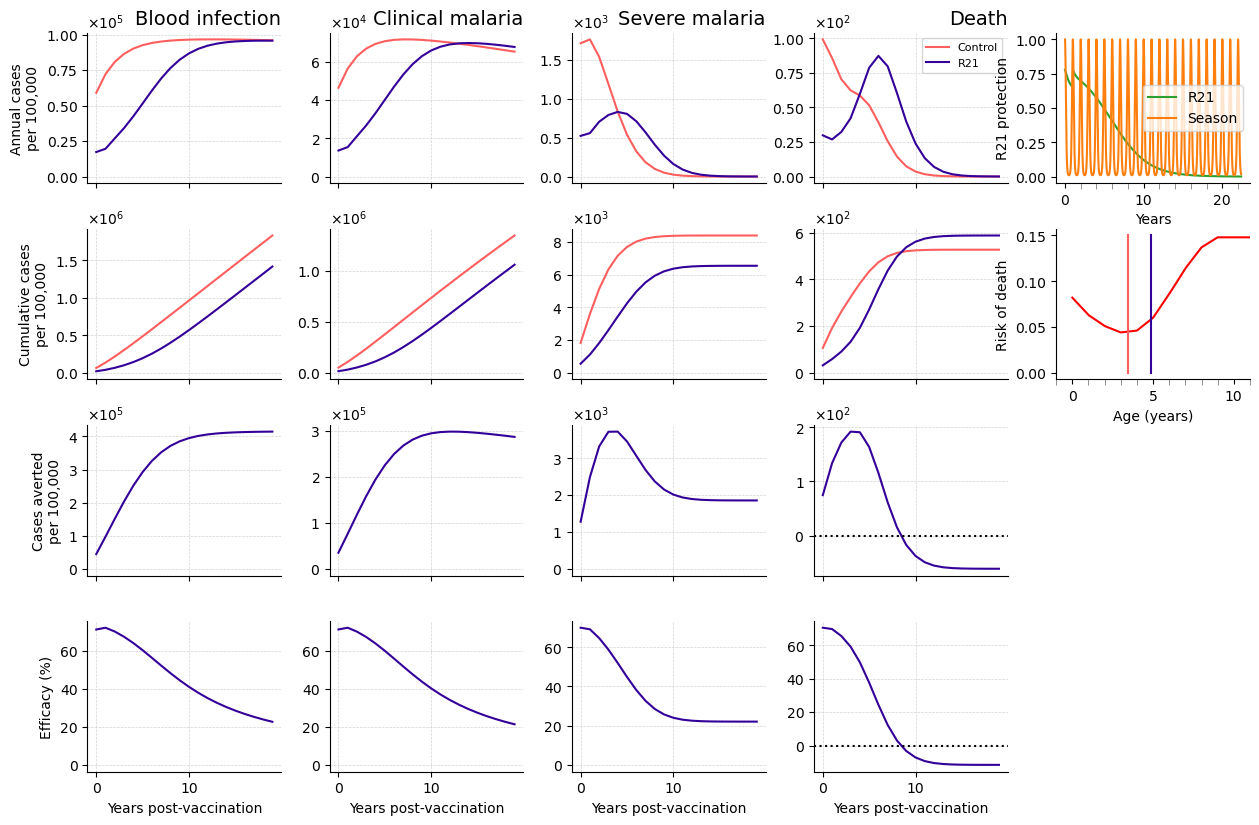

In [11]:
model = Model()

# set which variables to display
model.variables = Variables(['All infection', 'All clinical', 'Severe malaria', 'Direct deaths'])

# set which measures of each variable to display
model.measures = Measures(['cases', 'cdf', 'averted', 'efficacy'])

# set plot configuration parameters
model.Config(time_scale='Years', fig_xscale=1, fig_yscale=0.8, show_season=True, show_vac=True, show_smc=True, show_death_rates=True)

# if plotting additional panels (eg vaccine protection or seasons) set panels_fn to populate panels
model.Sources(panels_fn=panels)

# set simulation model parameters, see ../Edinburgh_Model/model.py for parameter definitions
model.pars = Parameters(
    lsv=True,
    bsv=False,
    smc=False,
    popsize=100000,
    λ=1,
    β=0,
    children='cohort',
    study_months=21*12,
    season_peak=0,
    season_width=0.1,
    min_vac_age=int(5*weeks_per_month),
    vac_age_range=int(12*weeks_per_month),
    smc_offset=0,
    smc_repeats=4,
    nboosters_blood=1,
    nboosters_liver=1,
    protection_blood=False,
    recording='Last primary dose',
    control='Control',
    treatment='R21',
)

# simulate the model and return a pandas DataFrame with the results
sim1 = simulation_single_vaccine(model)

# plot the results with the cohort names
fig, axs = plot(model, ['Control', 'R21'], sim1)

### Compare RTS,S and R21

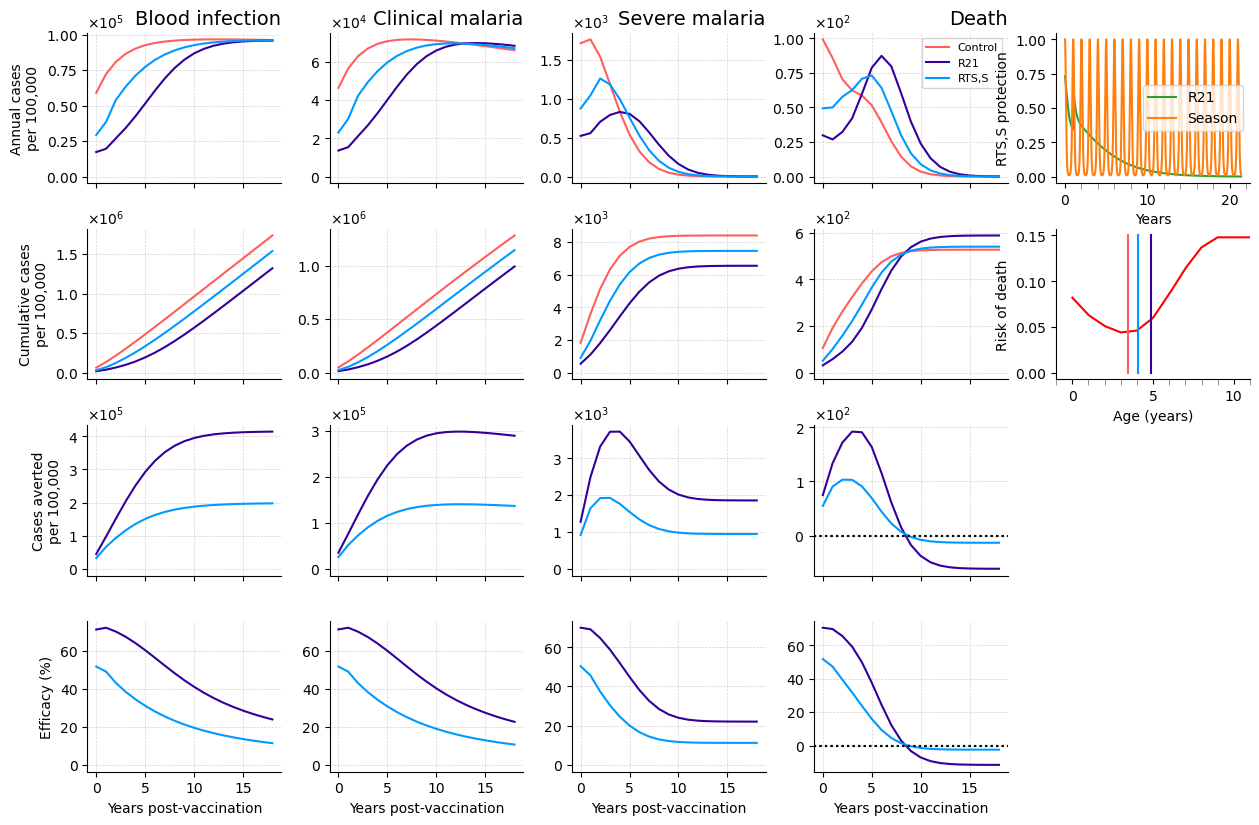

In [8]:
# We can use the same model defined above and just change the parameter "vac_profile_liver"
# and rename the treatment so that it is different from the previous simulation
model.pars.treatment = 'RTS,S'
# change the pre-erythrocytic vaccine profile to RTS,S and update the internal model parameters
model.pars.vac_profile_liver = 'Imperial RTS,S'
model.pars.update_pars('vac_profile_liver')

sim2 = simulation_single_vaccine(model)

# remove Control cohort form sim2 so that it is not plotted
sim2 = sim2.loc[:, ~sim2.columns.str.contains("Control")]
# merge the dataframes from the two simulations on column "ages"
both_sims = sim1.merge(sim2, on='ages')

fig, axs = plot(model, ['Control', 'R21', 'RTS,S'], both_sims)